In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cvxpy as cp
from IPython.display import display

34 paires | 1573 jours
['AUDUSD', 'CADJPY', 'CHFJPY', 'EURAUD', 'EURCAD', 'EURJPY', 'EURUSD', 'GBPAUD', 'GBPCAD', 'GBPUSD', 'NZDJPY', 'NZDUSD', 'USDBRL', 'USDCAD', 'USDCHF', 'USDCLP', 'USDCNY', 'USDCZK', 'USDDKK', 'USDHKD', 'USDHUF', 'USDILS', 'USDINR', 'USDJPY', 'USDKRW', 'USDMXN', 'USDNOK', 'USDPKR', 'USDPLN', 'USDRUB', 'USDSEK', 'USDSGD', 'USDTRY', 'USDZAR']

Dataset : 51475 observations x 5 features
Labels positifs : 47.9%

       sharpe_30     vol_20  vol_ratio  win_rate_20  autocorr_lag1      label
count  51475.000  51475.000  51475.000    51475.000      51475.000  51475.000
mean       0.239      0.103      0.968        0.505         -0.074      0.479
std        2.611      0.301      0.231        0.114          0.198      0.500
min       -5.000      0.001      0.012        0.100         -0.866      0.000
25%       -1.605      0.058      0.832        0.450         -0.203      0.000
50%        0.234      0.081      0.969        0.500         -0.070      0.000
75%        2.105      

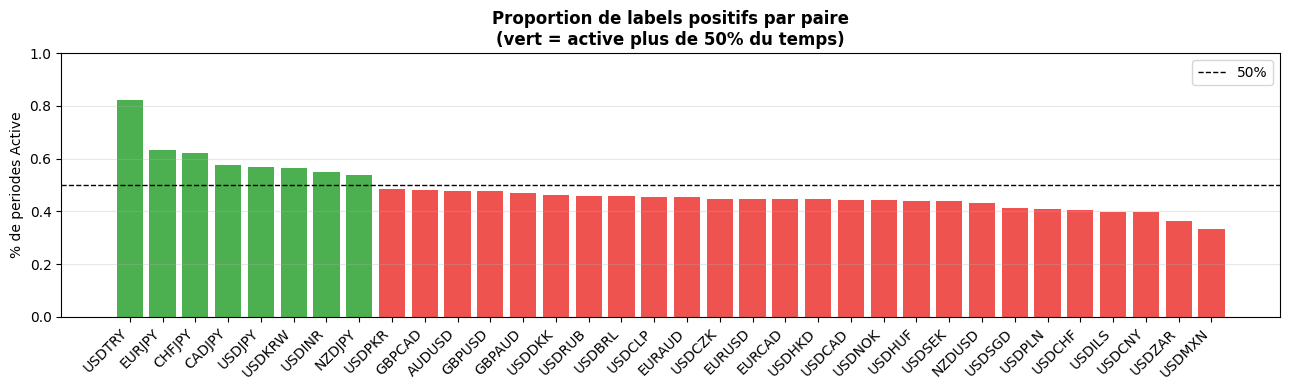

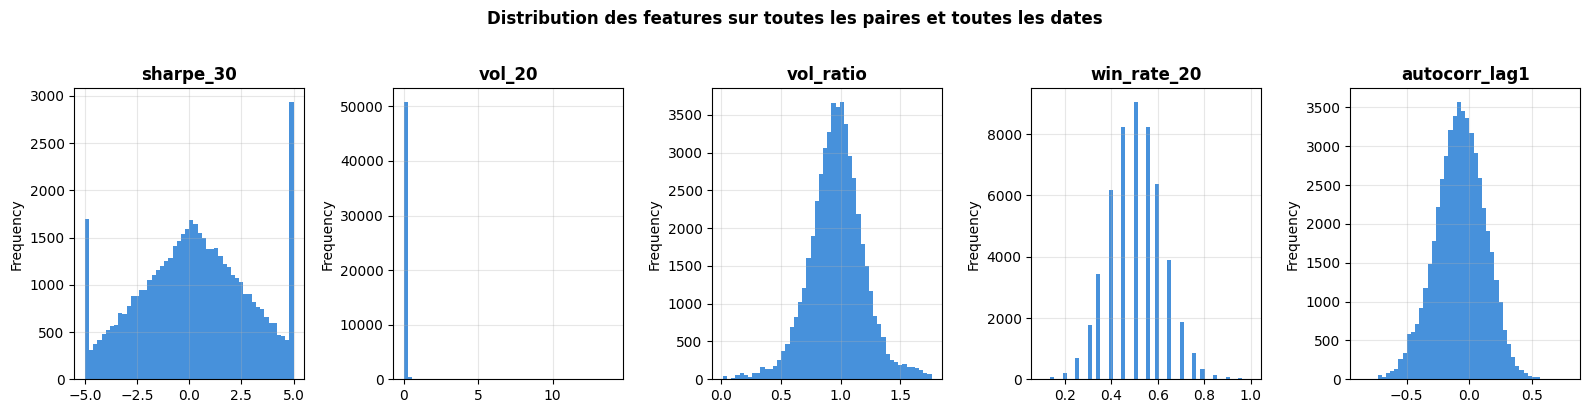


Resultats walk-forward validation :
            Periode test    AUC     F1  Accuracy
Fold                                            
1     2021-05 -> 2022-07  0.472  0.559     0.489
2     2022-07 -> 2023-09  0.491  0.577     0.506
3     2023-09 -> 2024-11  0.475  0.565     0.476
4     2024-11 -> 2026-01  0.507  0.456     0.470

AUC moyenne : 0.486 +/- 0.016
F1 moyenne  : 0.539 +/- 0.056


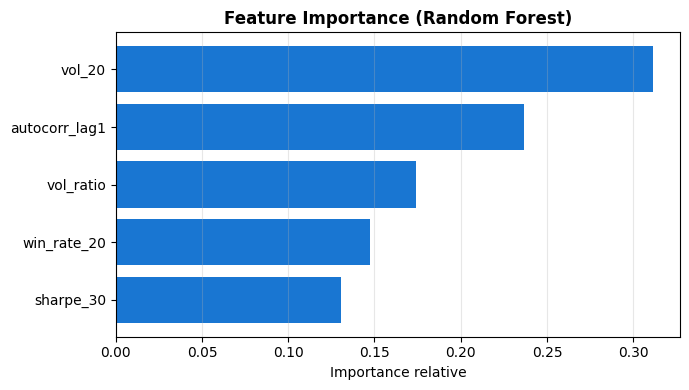

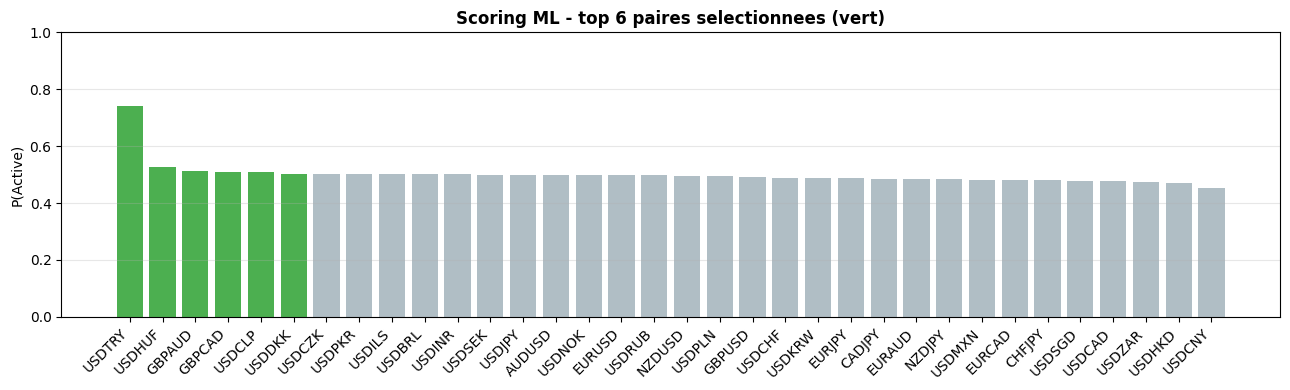


Resultats sauvegardes dans ./outputs_ml/

Paires selectionnees :
 Rang  Paire  P(Active)
    1 USDTRY      0.742
    2 USDHUF      0.526
    3 GBPAUD      0.513
    4 GBPCAD      0.510
    5 USDCLP      0.509
    6 USDDKK      0.503


In [3]:
#!/usr/bin/env python
# coding: utf-8

# =============================================================================
# Sélection des paires FX par Machine Learning — Groupe 487
# =============================================================================

# -- 0. Imports & configuration -----------------------------------------------

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

warnings.filterwarnings("ignore")

FX_RETURNS   = "./fx_returns.csv"   # chemin vers le fichier de returns.py
OUTPUT_DIR   = "./outputs_ml"
TRADING_DAYS = 252
FORWARD_H    = 30     # horizon du label (jours de trading)
SHARPE_SEUIL = 0.3    # seuil pour classer "Active"
N_ACTIVE     = 6      # nombre de paires à sélectionner

os.makedirs(OUTPUT_DIR, exist_ok=True)


# -- 1. Chargement des données ------------------------------------------------

returns_df = pd.read_csv(FX_RETURNS, sep=";", decimal=",", index_col=0, parse_dates=True)
returns_df = returns_df.dropna(how="all")

print(f"{len(returns_df.columns)} paires | {len(returns_df)} jours")
print(list(returns_df.columns))


# -- 2. Définition du label ---------------------------------------------------
# Pour chaque paire et chaque date t, on calcule le Sharpe des 30 prochains jours.
# Si ce Sharpe dépasse 0.3 la paire est Active (1) sinon Inactive (0).

def make_label(r):
    r_future = r.shift(-1)
    # shift(-1) : on regarde les rendements futurs sans utiliser le jour t lui-meme
    def sharpe(x):
        s = x.std()
        return (x.mean() / s * np.sqrt(TRADING_DAYS)) if s > 1e-8 else 0.0
    forward_sharpe = r_future.rolling(FORWARD_H).apply(sharpe, raw=True).shift(-(FORWARD_H - 1))
    return (forward_sharpe > SHARPE_SEUIL).astype(int).rename("label")


# -- 3. Définition des features -----------------------------------------------
# 5 indicateurs calculés uniquement sur le passé (aucune fuite vers le futur)

FEATURE_COLS = ["sharpe_30", "vol_20", "vol_ratio", "win_rate_20", "autocorr_lag1"]

def make_features(r):
    f = pd.DataFrame(index=r.index)

    mu_30  = r.rolling(30).mean() * TRADING_DAYS
    sig_30 = r.rolling(30).std()  * np.sqrt(TRADING_DAYS)
    f["sharpe_30"]     = (mu_30 / sig_30.replace(0, np.nan)).clip(-5, 5)

    vol_20 = r.rolling(20).std() * np.sqrt(TRADING_DAYS)
    vol_60 = r.rolling(60).std() * np.sqrt(TRADING_DAYS)
    f["vol_20"]        = vol_20
    f["vol_ratio"]     = (vol_20 / vol_60.replace(0, np.nan)).clip(0, 5)

    f["win_rate_20"]   = r.rolling(20).apply(lambda x: (x > 0).mean(), raw=True)
    f["autocorr_lag1"] = r.rolling(30).apply(
        lambda x: pd.Series(x).autocorr(lag=1) if len(x) > 2 else 0.0, raw=True
    ).fillna(0.0).clip(-1, 1)

    return f


# -- 4. Construction du dataset -----------------------------------------------
# On empile les features et le label de chaque paire dans un seul dataframe trié par date.

chunks = []
for pair in returns_df.columns:
    r = returns_df[pair].dropna()
    merged = make_features(r).join(make_label(r), how="inner").dropna()
    merged.insert(0, "pair", pair)
    if len(merged) >= 100:
        chunks.append(merged)

dataset = pd.concat(chunks).sort_index()
print(f"\nDataset : {len(dataset)} observations x {len(FEATURE_COLS)} features")
print(f"Labels positifs : {dataset['label'].mean():.1%}\n")
print(dataset[FEATURE_COLS + ["label"]].describe().round(3))
print("\nApercu du dataset :")
print(dataset.head(10))

# Graphique : proportion de labels positifs par paire
label_by_pair = dataset.groupby("pair")["label"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
colors = ["#4CAF50" if v > 0.5 else "#EF5350" for v in label_by_pair.values]
ax.bar(label_by_pair.index, label_by_pair.values, color=colors)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="50%")
ax.set_ylim(0, 1)
ax.set_ylabel("% de periodes Active")
ax.set_title("Proportion de labels positifs par paire\n(vert = active plus de 50% du temps)", fontweight="bold")
ax.set_xticklabels(label_by_pair.index, rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "label_by_pair.png"), dpi=150, bbox_inches="tight")
plt.show()

# Graphique : distribution des features
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, FEATURE_COLS):
    dataset[col].dropna().plot.hist(bins=50, ax=ax, color="#1976D2", alpha=0.8)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.grid(alpha=0.3)
fig.suptitle("Distribution des features sur toutes les paires et toutes les dates",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()


# -- 5. Walk-forward validation -----------------------------------------------
# On découpe la période en 4 tranches chronologiques.
# Le modèle apprend sur le passé et on teste sur ce qui suit immédiatement.

X = dataset[FEATURE_COLS].values
y = dataset["label"].values

tscv = TimeSeriesSplit(n_splits=4)
results_cv = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=15,
        class_weight="balanced", random_state=42, n_jobs=-1
    )
    rf.fit(X[train_idx], y[train_idx])
    proba = rf.predict_proba(X[test_idx])[:, 1]
    pred  = rf.predict(X[test_idx])

    d_start = dataset.index[test_idx[0]].strftime("%Y-%m")
    d_end   = dataset.index[test_idx[-1]].strftime("%Y-%m")

    results_cv.append({
        "Fold": fold + 1,
        "Periode test": f"{d_start} -> {d_end}",
        "AUC": round(roc_auc_score(y[test_idx], proba), 3),
        "F1":  round(f1_score(y[test_idx], pred, zero_division=0), 3),
        "Accuracy": round(accuracy_score(y[test_idx], pred), 3),
    })

cv_df = pd.DataFrame(results_cv).set_index("Fold")
print("\nResultats walk-forward validation :")
print(cv_df)
print(f"\nAUC moyenne : {cv_df['AUC'].mean():.3f} +/- {cv_df['AUC'].std():.3f}")
print(f"F1 moyenne  : {cv_df['F1'].mean():.3f} +/- {cv_df['F1'].std():.3f}")


# -- 6. Modèle final & feature importance -------------------------------------
# On réentraine sur tout le dataset pour le modèle de production.

model = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=15,
    class_weight="balanced", random_state=42, n_jobs=-1
)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance.index, importance.values, color="#1976D2")
ax.set_xlabel("Importance relative")
ax.set_title("Feature Importance (Random Forest)", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()


# -- 7. Scoring final ---------------------------------------------------------
# Pour chaque paire, on donne les indicateurs d'aujourd'hui au modèle.
# Il estime une probabilité d'être performante le mois prochain.
# On prend les N_ACTIVE meilleures.

rows = []
for pair in returns_df.columns:
    sub = dataset[dataset["pair"] == pair][FEATURE_COLS].dropna()
    if sub.empty:
        continue
    proba = model.predict_proba(sub.iloc[[-1]])[:, 1][0]
    rows.append({"Paire": pair, "P(Active)": round(proba, 3)})

scores = (pd.DataFrame(rows)
          .sort_values("P(Active)", ascending=False)
          .reset_index(drop=True))
scores["Rang"]   = scores.index + 1
scores["Statut"] = ["ACTIVE" if i < N_ACTIVE else "inactive" for i in range(len(scores))]

colors = ["#4CAF50" if s == "ACTIVE" else "#B0BEC5" for s in scores["Statut"]]
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(scores["Paire"], scores["P(Active)"], color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel("P(Active)")
ax.set_title(f"Scoring ML - top {N_ACTIVE} paires selectionnees (vert)", fontweight="bold")
ax.set_xticklabels(scores["Paire"], rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pair_scores.png"), dpi=150, bbox_inches="tight")
plt.show()


# -- 8. Export ----------------------------------------------------------------

scores.to_csv(os.path.join(OUTPUT_DIR, "pair_scores.csv"), index=False)
print(f"\nResultats sauvegardes dans {OUTPUT_DIR}/")
print("\nPaires selectionnees :")
print(scores[scores["Statut"] == "ACTIVE"][["Rang", "Paire", "P(Active)"]].to_string(index=False))

In [20]:
returns_df = pd.read_csv(
    "fx_returns.csv",
    sep=";",
    decimal=",",
    index_col=0,
    parse_dates=True
)

returns_df = returns_df.sort_index()
returns_df = returns_df.dropna(how="any")

print(returns_df.head())
print("Shape:", returns_df.shape)


              AUDUSD    CADJPY    CHFJPY    EURAUD    EURCAD    EURJPY  \
Date                                                                     
2020-01-02  0.000358 -0.005370 -0.002916 -0.000694 -0.001023  0.000025   
2020-01-03 -0.004902 -0.002032 -0.005464  0.000782 -0.003600 -0.005986   
2020-01-06 -0.005885 -0.005687 -0.005197  0.004859 -0.000483 -0.006155   
2020-01-07 -0.000993  0.005998  0.007326  0.004048  0.001207  0.007103   
2020-01-08 -0.011149 -0.006551 -0.004109  0.007415 -0.000710 -0.007236   

              EURUSD    GBPAUD    GBPCAD    GBPUSD  ...    USDKRW    USDMXN  \
Date                                                ...                       
2020-01-02  0.000000 -0.003455 -0.002260 -0.000928  ...  0.000191 -0.000984   
2020-01-03 -0.004411 -0.002684 -0.007304 -0.007393  ...  0.002752 -0.003631   
2020-01-06 -0.000849  0.000409 -0.004710 -0.005535  ...  0.007490  0.006060   
2020-01-07  0.003223  0.007986  0.005167  0.006851  ...  0.001346 -0.005468   
2020-01

In [21]:
## Filtrage avec le ml
scores = pd.read_csv("./outputs_ml/pair_scores.csv")

selected_pairs = scores.loc[
    scores["Statut"] == "ACTIVE",
    "Paire"
].tolist()

print("Paires sélectionnées :", selected_pairs)

Paires sélectionnées : ['USDTRY', 'USDHUF', 'GBPAUD', 'GBPCAD', 'USDCLP', 'USDDKK']


In [22]:
returns_df = returns_df[selected_pairs]

In [23]:
print(returns_df.describe())

            USDTRY       USDHUF       GBPAUD       GBPCAD       USDCLP  \
count  1572.000000  1572.000000  1572.000000  1572.000000  1572.000000   
mean      0.001248     0.000063     0.000033     0.000047     0.000106   
std       0.010750     0.007826     0.004886     0.004605     0.010622   
min      -0.209041    -0.047459    -0.026654    -0.034368    -0.124883   
25%      -0.000649    -0.004443    -0.002811    -0.002509    -0.005997   
50%       0.000686    -0.000134    -0.000022     0.000098    -0.000247   
75%       0.002694     0.004500     0.002899     0.002479     0.005696   
max       0.116772     0.037235     0.040841     0.033812     0.042772   

            USDDKK  
count  1572.000000  
mean     -0.000024  
std       0.004705  
min      -0.027515  
25%      -0.002807  
50%       0.000074  
75%       0.002651  
max       0.027897  


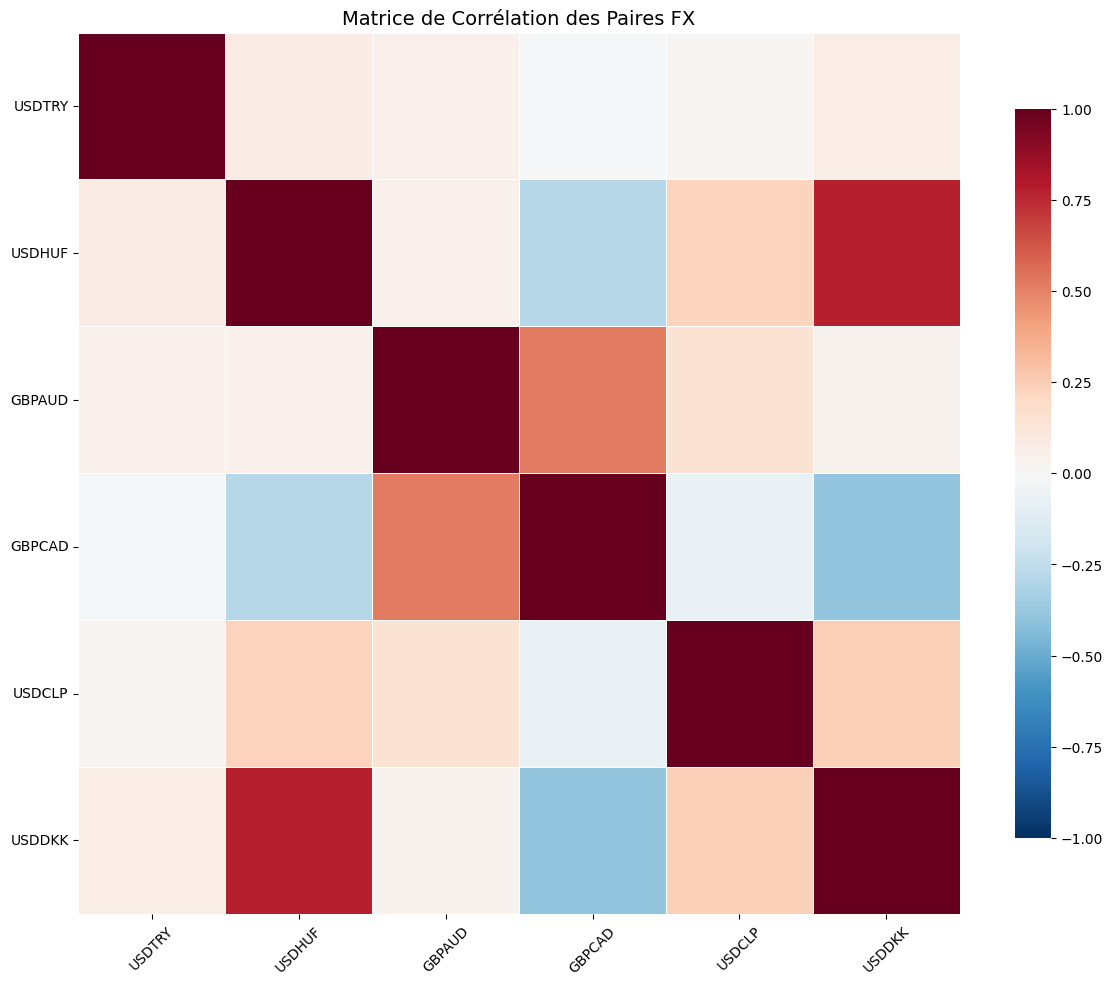

In [24]:
# corrélations des paires

# Matrice de corrélation
corr = returns_df.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    cmap="RdBu_r",      # rouge = corr positive, bleu = négative
    center=0,           # centre la couleur sur 0
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matrice de Corrélation des Paires FX", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
TRADING_DAYS = 252
WINDOW = 60  # fenêtre de 60 jours

def mu_sigma_at_date(returns_df, end_date):
    r = returns_df.loc[returns_df.index < end_date].dropna(how="any")
    r_win = r.iloc[-WINDOW:]

    mu = r_win.mean() * TRADING_DAYS
    Sigma = r_win.cov() * TRADING_DAYS

    return mu, Sigma


In [26]:
test_date = returns_df.index[100]
mu_t, Sigma_t = mu_sigma_at_date(returns_df, test_date)

print(mu_t.head())
print(Sigma_t.shape)


USDTRY    0.317226
USDHUF    0.030478
GBPAUD   -0.254316
GBPCAD   -0.079613
USDCLP   -0.116261
dtype: float64
(6, 6)


In [27]:
print("Mean of mu_t:", mu_t.mean())
print("Std of mu_t:", mu_t.std())

Mean of mu_t: -0.024485804158257313
Std of mu_t: 0.1920775705281975


In [28]:
# Vérifier que la matrice a les bonnes valeurs et est bien conditionnée
# (ici non donc on rajoute un ridge dans la fonction suivante)

eig_min = np.linalg.eigvalsh(Sigma_t.values).min()
eig_max = np.linalg.eigvalsh(Sigma_t.values).max()
cond = eig_max / max(eig_min, 1e-12)

print("min eigenvalue:", eig_min)
print("max eigenvalue:", eig_max)
print("condition approx:", cond)


min eigenvalue: 0.0026904826199820736
max eigenvalue: 0.0490493464615292
condition approx: 18.23068697684284


In [29]:
# --- 1. Fonctions d'Optimisation (CVXPY) ---

def solve_min_variance(mu, Sigma, cap=0.2, eps=1e-4):
    """Minimise la variance du portefeuille."""
    n = len(mu)
    Sigma_psd = Sigma + eps * np.eye(n) # Régularisation

    w = cp.Variable(n)
    objective = cp.Minimize(cp.quad_form(w, Sigma_psd))

    # Contraintes : somme=1, poids positifs, poids max <= cap
    constraints = [cp.sum(w) == 1, w >= 0]
    if cap is not None: constraints.append(w <= cap)

    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.SCS, verbose=False)
        return np.maximum(w.value, 0) # Nettoyage des petites valeurs négatives
    except:
        return np.ones(n)/n # Fallback équipondéré si échec

def solve_max_return(mu, Sigma, cap=0.2, eps=1e-4):
    """Maximise le rendement espéré (Attention: très risqué)."""
    n = len(mu)
    w = cp.Variable(n)
    objective = cp.Maximize(mu @ w)

    constraints = [cp.sum(w) == 1, w >= 0]
    if cap is not None: constraints.append(w <= cap)

    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.SCS, verbose=False)
        return np.maximum(w.value, 0)
    except:
        return np.ones(n)/n

def solve_max_sharpe(mu, Sigma, cap=0.2, eps=1e-4):
    """
    Maximise le Ratio de Sharpe.
    Utilise la transformation de Charnes-Cooper pour rendre le problème convexe.
    """
    n = len(mu)
    # Si tous les rendements sont négatifs, on se rabat sur le Min Variance
    if np.max(mu) < 0:
        return solve_min_variance(mu, Sigma, cap, eps)

    Sigma_psd = Sigma + eps * np.eye(n)

    # Changement de variable : y = w / k
    y = cp.Variable(n)
    k = cp.Variable()

    # Maximize mu^T * y
    objective = cp.Maximize(mu @ y)

    constraints = [
        cp.quad_form(y, Sigma_psd) <= 1, # Variance bornée dans l'espace transformé
        cp.sum(y) == k,
        y >= 0,
        k >= 0
    ]

    if cap is not None:
        constraints.append(y <= cap * k) # w <= cap devient y <= cap * k

    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.SCS, verbose=False)
        if k.value is None or k.value < 1e-6: return np.ones(n)/n

        # Retour aux poids originaux w = y / k
        w_res = y.value / k.value
        return np.maximum(w_res, 0)
    except:
        return np.ones(n)/n

In [30]:
# --- 2. Moteur de Backtest ---

def run_backtest(returns_df, strategy_fn, window=60, cap=0.2):
    # Fréquence de rebalancement : Début de mois (MS)
    rebal_dates = returns_df.resample("MS").first().index
    portfolio_daily_returns = []

    # Date de début effective (après la première fenêtre)
    start_idx = 0
    for i, date in enumerate(rebal_dates):
        if len(returns_df.loc[:date]) >= window:
            start_idx = i
            break

    current_weights = np.ones(returns_df.shape[1]) / returns_df.shape[1]
    TRADING_DAYS = 252

    for i in range(start_idx, len(rebal_dates)):
        curr_date = rebal_dates[i]
        # Prochaine date de rebalancement (ou fin des données)
        next_date = rebal_dates[i+1] if i < len(rebal_dates)-1 else returns_df.index[-1]

        # 1. Données historiques pour l'optimisation
        hist_data = returns_df.loc[:curr_date].iloc[-window:]

        # Calcul Mu et Sigma annualisés
        mu = hist_data.mean().values * TRADING_DAYS
        Sigma = hist_data.cov().values * TRADING_DAYS

        # 2. Optimisation des poids
        try:
            w = strategy_fn(mu, Sigma, cap=cap)
            # Normalisation pour être sûr que somme(w) = 1
            if np.sum(w) > 0: w = w / np.sum(w)
        except Exception as e:
            print(f"Erreur opti {curr_date}: {e}")
            w = current_weights

        current_weights = w

        # 3. Application sur la période suivante (curr_date à next_date]
        mask = (returns_df.index > curr_date) & (returns_df.index <= next_date)
        period_returns = returns_df.loc[mask]

        if period_returns.empty: continue

        # Rendement du portefeuille = produit scalaire
        p_rets = period_returns.dot(w)
        portfolio_daily_returns.append(p_rets)

    return pd.concat(portfolio_daily_returns)

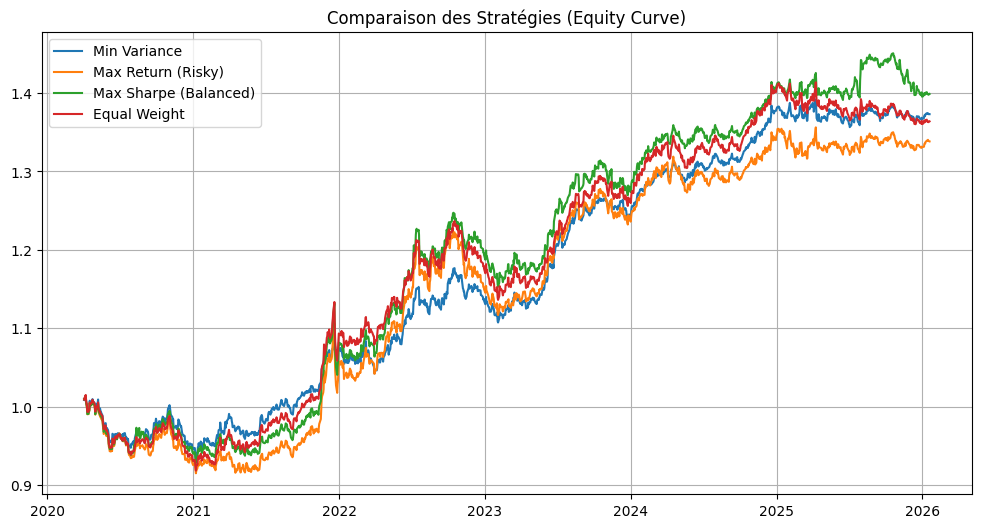

In [49]:
# --- 3. Exécution et Comparaison ---

# Lancer les 3 backtests
ret_mv = run_backtest(returns_df, solve_min_variance, window=60)
ret_mr = run_backtest(returns_df, solve_max_return, window=60)
ret_ms = run_backtest(returns_df, solve_max_sharpe, window=60)
def solve_equal_weight(mu, Sigma, cap=None):
    n = len(mu)
    return np.ones(n) / n

ret_eq = run_backtest(returns_df, solve_equal_weight, window=60)

# Créer un DataFrame pour les courbes
equity_df = pd.DataFrame({
    "Min Variance": (1 + ret_mv).cumprod(),
    "Max Return (Risky)": (1 + ret_mr).cumprod(),
    "Max Sharpe (Balanced)": (1 + ret_ms).cumprod(),
    "Equal Weight": (1 + ret_eq).cumprod()
})

strategies = {
    "Min Variance": ret_mv,
    "Max Return": ret_mr,
    "Max Sharpe": ret_ms,
    "Equal Weight": ret_eq
}

# Tracer
plt.figure(figsize=(12, 6))
plt.plot(equity_df)
plt.title("Comparaison des Stratégies (Equity Curve)")
plt.legend(equity_df.columns)
plt.grid(True)
plt.show()

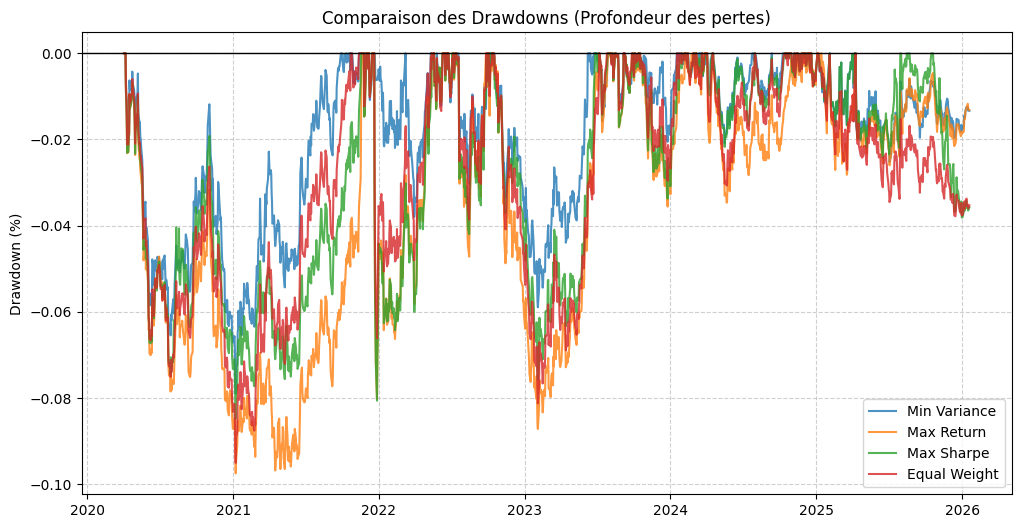

In [50]:
def plot_combined_drawdowns(returns_data):
    plt.figure(figsize=(12, 6))

    for name, r in returns_data.items():
        if r is None or len(r) == 0: continue

        equity = (1 + r).cumprod()
        peak = equity.cummax()
        drawdown = (equity - peak) / peak

        plt.plot(drawdown.index, drawdown, label=name, linewidth=1.5, alpha=0.8)


    plt.title("Comparaison des Drawdowns (Profondeur des pertes)")
    plt.ylabel("Drawdown (%)")
    plt.axhline(0, color='black', lw=1) # Ligne zéro
    plt.legend()
    plt.grid(True, which="major", linestyle="--", alpha=0.6)
    plt.show()

plot_combined_drawdowns(strategies)

#Métriques

In [33]:
def get_metrics_table(returns_data, risk_free_rate=0.0):
    """
    Génère un tableau de métriques de performance pour vos portefeuilles.

    Args:
        returns_data (dict): Dictionnaire contenant vos séries de rendements.
                             Ex: {"Min Var": ret_mv, "Max Sharpe": ret_ms}
        risk_free_rate (float): Taux sans risque annuel (par défaut 0.0)

    Returns:
        pd.DataFrame: Tableau comparatif des performances
    """
    metrics = []
    TRADING_DAYS = 252

    # On itère sur chaque stratégie du dictionnaire
    for name, r in returns_data.items():
        if r is None or len(r) == 0:
            continue

        # Calcul de la courbe d'equity
        equity = (1 + r).cumprod()

        # Rendement Total (Fin / Début - 1)
        total_ret = equity.iloc[-1] - 1

        # Volatilité Annualisée (Std Dev * sqrt(252))
        ann_vol = r.std() * np.sqrt(TRADING_DAYS)

        # Ratio de Sharpe (Rendement Annuel / Volatilité Annuelle)
        ann_ret = r.mean() * TRADING_DAYS
        sharpe = (ann_ret - risk_free_rate) / ann_vol if ann_vol != 0 else 0

        # Max Drawdown (Perte maximale depuis un sommet
        peak = equity.cummax()
        drawdown = (equity - peak) / peak
        max_dd = drawdown.min()

        # Ajout au tableau
        metrics.append({
            "Stratégie": name,
            "Rendement Total": total_ret,
            "Volatilité (An)": ann_vol,
            "Ratio de Sharpe": sharpe,
            "Max Drawdown": max_dd
        })

    # Création du DataFrame final
    df = pd.DataFrame(metrics)
    if not df.empty:
        df = df.set_index("Stratégie")

    return df

In [34]:
df_results = get_metrics_table(strategies)
styled_table = df_results.style.format({
    'Rendement Total': '{:+.1%}',
    'Volatilité (An)': '{:.1%}',
    'Ratio de Sharpe': '{:.2f}',
    'Max Drawdown': '{:.1%}'
}).background_gradient(subset=['Ratio de Sharpe'], cmap='RdYlGn')

display(styled_table)

,Rendement Total,Volatilité (An),Ratio de Sharpe,Max Drawdown
Stratégie,,,,
Min Variance,+37.3%,4.9%,1.10,-7.9%
Max Return,+33.8%,6.3%,0.80,-9.7%
Max Sharpe,+39.9%,6.2%,0.93,-8.5%
